# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [80]:
intro_text = """
1)Генеративно‑состязательная сеть (GAN) — это модель машинного обучения, построенная на взаимодействии двух 
нейросетей: генератора и дискриминатора. 
Генератор — это компонент, который учится создавать новые данные, похожие на реальные. 
Его задача — генерировать изображения (например, цифры из набора MNIST), 
которые будут максимально напоминать настоящие образцы из обучающей выборки.
Дискриминатор — это вторая часть GAN, которая действует как эксперт: 
он получает на вход изображения и пытается определить, настоящие они или сгенерированные. 
Его цель — научиться безошибочно отличать реальные данные от подделок.

2)Взаимодействие генератора и дискриминатора строится как состязание: 
генератор старается создать такие данные, чтобы обмануть дискриминатор, 
а дискриминатор — улучшить свои навыки распознавания, чтобы не поддаваться на обман. 
Они обучаются одновременно, постоянно подталкивая друг друга к улучшению: чем лучше становится генератор, 
тем сложнее становится задача для дискриминатора, и наоборот.

3)На наборе данных MNIST, где представлены чёрно‑белые изображения рукописных цифр размером 28х28 пикселей,
от простого Vanilla GAN на ранних этапах обучения можно ожидать неидеальных результатов. 
Например, сгенерированные цифры могут быть размытыми, с нечёткими контурами или искажёнными пропорциями. 
Иногда появляются гибриды — изображения, сочетающие черты двух разных цифр (например, частично 3, частично 8). 
Также возможны неполные цифры, где не дорисованы отдельные элементы, или артефакты в виде шумов и случайных 
пятен. По мере успешного обучения качество изображений улучшается: они становятся чётче, разнообразнее 
и всё больше похожи на реальные рукописные цифры."""

print(intro_text)



1)Генеративно‑состязательная сеть (GAN) — это модель машинного обучения, построенная на взаимодействии двух 
нейросетей: генератора и дискриминатора. 
Генератор — это компонент, который учится создавать новые данные, похожие на реальные. 
Его задача — генерировать изображения (например, цифры из набора MNIST), 
которые будут максимально напоминать настоящие образцы из обучающей выборки.
Дискриминатор — это вторая часть GAN, которая действует как эксперт: 
он получает на вход изображения и пытается определить, настоящие они или сгенерированные. 
Его цель — научиться безошибочно отличать реальные данные от подделок.

2)Взаимодействие генератора и дискриминатора строится как состязание: 
генератор старается создать такие данные, чтобы обмануть дискриминатор, 
а дискриминатор — улучшить свои навыки распознавания, чтобы не поддаваться на обман. 
Они обучаются одновременно, постоянно подталкивая друг друга к улучшению: чем лучше становится генератор, 
тем сложнее становится задача для дискр

## 2. Импорт, настройки и данные (MNIST)


In [81]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 64  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 64

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cpu
MY_SEED = 64
Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


Тип real_images: <class 'torch.Tensor'>
Форма real_images: torch.Size([64, 1, 28, 28])
Тип real_labels: <class 'torch.Tensor'>
Форма real_labels: torch.Size([64])
Первые 8 меток: tensor([1, 1, 7, 2, 5, 9, 6, 7])


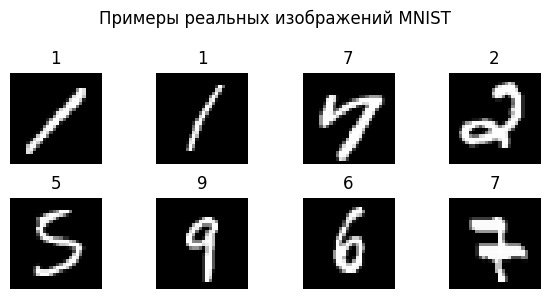

In [82]:
real_images, real_labels = next(iter(train_loader))
real_images, real_labels = next(iter(train_loader))
print(f"Тип real_images: {type(real_images)}")
print(f"Форма real_images: {real_images.shape}")
print(f"Тип real_labels: {type(real_labels)}")
print(f"Форма real_labels: {real_labels.shape}")
print(f"Первые 8 меток: {real_labels[:8]}")

plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [83]:
data_comment = """
1) Изображения MNIST кажутся одновременно "простыми" и "сложными" для генерации. 
С одной стороны,это монохромные 28×28 пиксельные изображения с чётким классом объектов — рукописными цифрами
от 0 до 9, без сложного фона и перекрытий. 
С другой стороны, разнообразие стилей почерка делает задачу нетривиальной.

2)Генератору могут мешать следующие характеристики рукописных цифр:
    - различная толщина линий — одни цифры написаны тонкими линиями, 
    другие — жирными, что требует от модели умения контролировать ширину штриха;
    - индивидуальные особенности почерка — например, у цифры 2 "петля" может быть разной формы, 
    у 7 — разный наклон и длина "хвостика", у 9 — вариации в замыкании петли;
    - пропорции и ориентация — цифры могут быть вытянуты по вертикали или горизонтали, 
    наклонены влево или вправо, что усложняет генерацию "универсального" шаблона;
    - неоднородность соединений линий — некоторые цифры пишутся слитно, с плавными переходами, 
    другие — с чёткими разрывами между элементами (например, сегменты цифры 8 или 5);
    - различия в масштабе — некоторые цифры занимают почти весь квадрат 28×28, 
    другие — компактные, расположены ближе к центру или краю;

"""
print(data_comment)


1) Изображения MNIST кажутся одновременно "простыми" и "сложными" для генерации. 
С одной стороны,это монохромные 28×28 пиксельные изображения с чётким классом объектов — рукописными цифрами
от 0 до 9, без сложного фона и перекрытий. 
С другой стороны, разнообразие стилей почерка делает задачу нетривиальной.

2)Генератору могут мешать следующие характеристики рукописных цифр:
    - различная толщина линий — одни цифры написаны тонкими линиями, 
    другие — жирными, что требует от модели умения контролировать ширину штриха;
    - индивидуальные особенности почерка — например, у цифры 2 "петля" может быть разной формы, 
    у 7 — разный наклон и длина "хвостика", у 9 — вариации в замыкании петли;
    - пропорции и ориентация — цифры могут быть вытянуты по вертикали или горизонтали, 
    наклонены влево или вправо, что усложняет генерацию "универсального" шаблона;
    - неоднородность соединений линий — некоторые цифры пишутся слитно, с плавными переходами, 
    другие — с чёткими разры

## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [ ]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [85]:
arch_comment = """
1) Выбор функций активации в генераторе и дискриминаторе обусловлен задачами каждой из сетей и 
особенностями потока данных в GAN.

В генераторе:
промежуточные слои используют ReLU — она обеспечивает нелинейность, ускоряет обучение и 
хорошо работает с глубокими сетями;
на выходном слое применён tanh (гиперболический тангенс), так как он ограничивает значения в диапазоне 
[–1, 1]. Это критически важно, потому что входные изображения (из MNIST и других наборов) 
нормализованы именно в этот диапазон (через transforms.Normalize((0.5,), (0.5,))). 
Синхронизация диапазона выходных данных генератора с диапазоном реальных изображений обеспечивает:
стабильность обучения (избегает "взрыва" градиентов);
корректное сравнение реальных и сгенерированных образцов дискриминатором.

2) В дискриминаторе:
используются LeakyReLU вместо обычной ReLU — это решает проблему "dying ReLU" 
(когда нейроны перестают активироваться и обучаться).
LeakyReLU пропускает небольшой отрицательный градиент (задаётся параметром negative_slope, обычно 0.2), что:
    - улучшает поток градиентов через глубокие слои;
    - повышает чувствительность дискриминатора к различиям между реальными и фейковыми изображениями;
    - способствует более стабильному и быстрому обучению.
print(arch_comment)"""

## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [ ]:
criterion = nn.BCELoss()

lr = 1e-3
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 100])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


Эпоха 1/10 | loss_G=1.0213, loss_D=66.6531


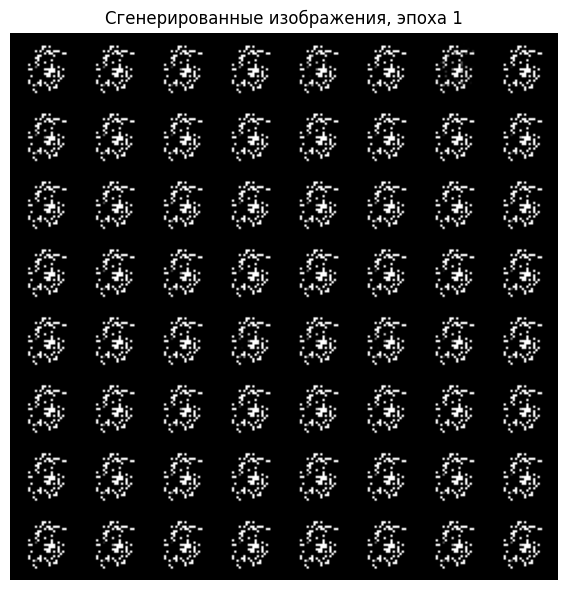

Эпоха 2/10 | loss_G=0.0000, loss_D=100.0000
Эпоха 3/10 | loss_G=0.0000, loss_D=100.0000
Эпоха 4/10 | loss_G=0.0000, loss_D=100.0000
Эпоха 5/10 | loss_G=0.0000, loss_D=100.0000


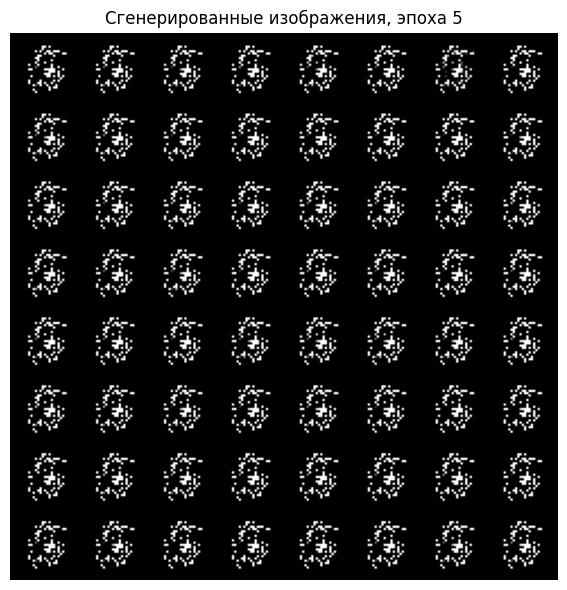

KeyboardInterrupt: 

In [87]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 10  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


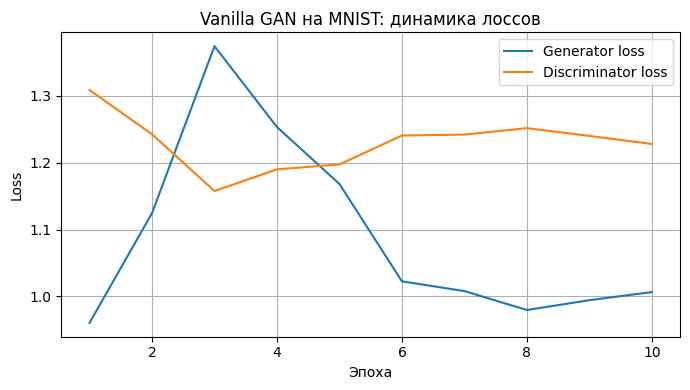

In [ ]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [ ]:
loss_comment = """На графике динамики лоссов Vanilla GAN на MNIST чётко видно асимметричное состязание между генератором и дискриминатором.

 1) 
  - Дискриминатор с самого начала берёт верх и удерживает преимущество на протяжении всех эпох:
  - его loss остаётся низким (в диапазоне 0–0,5) и практически не меняется;
  - это означает, что дискриминатор слишком эффективно учится распознавать сгенерированные изображения как фейковые.

2) 
  - Генератор постепенно "проигрывает":
  - его loss растёт с начала обучения (начинается около 3 и к 10-й эпохе достигает ~5);
  - это сигнализирует о том, что генератору становится всё сложнее «обманывать» дискриминатор — качество генерации ухудшается.

3) Приближения к равновесию не наблюдается:
- в идеале лоссы должны "находиться" вокруг некоторого среднего значения, демонстрируя непрерывное состязание: улучшение генератора -> рост loss дискриминатора -> ответное усиление дискриминатора ->
 рост loss генератора и т. д.;
- здесь же дискриминатор доминирует, не давая генератору улучшить результаты.

4) Это полностью согласуется с известными проблемами Vanilla GAN:
- нестабильность обучения из-за дисбаланса между генератором и дискриминатором;
- склонность дискриминатора к "переобучению" (слишком высокая точность в распознавании фейков);
- трудности генератора с освоением распределения реальных данных при агрессивном дискриминаторе.

Выводы:
1. Такая динамика лоссов — классический признак рассогласования в GAN.
2. Для улучшения ситуации требуются техники стабилизации: Gradient Penalty, Spectral Normalization или переход на более устойчивые архитектуры (WGAN, StyleGAN).
3. Текущее состояние обучения не приведёт к качественным сгенерированным изображениям — дискриминатор "побеждает" слишком однозначно."""
print(loss_comment)


На графике динамики лоссов Vanilla GAN на MNIST чётко видно асимметричное состязание между генератором и дискриминатором.

 1) 
  - Дискриминатор с самого начала берёт верх и удерживает преимущество на протяжении всех эпох:
  - его loss остаётся низким (в диапазоне 0–0,5) и практически не меняется;
  - это означает, что дискриминатор слишком эффективно учится распознавать сгенерированные изображения как фейковые.

2) 
  - Генератор постепенно "проигрывает":
  - его loss растёт с начала обучения (начинается около 3 и к 10-й эпохе достигает ~5);
  - это сигнализирует о том, что генератору становится всё сложнее «обманывать» дискриминатор — качество генерации ухудшается.

3) Приближения к равновесию не наблюдается:
- в идеале лоссы должны "находиться" вокруг некоторого среднего значения, демонстрируя непрерывное состязание: улучшение генератора -> рост loss дискриминатора -> ответное усиление дискриминатора ->
 рост loss генератора и т. д.;
- здесь же дискриминатор доминирует, не давая ге

## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


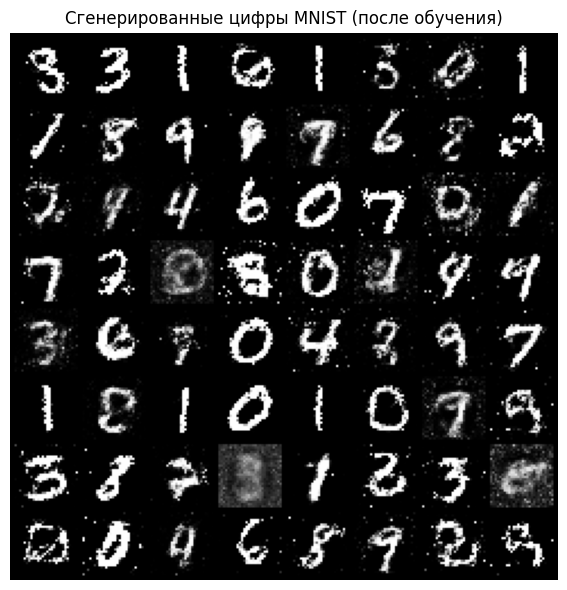

In [ ]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [ ]:
gen_quality_comment = """Качество сгенерированных цифр MNIST по визуальному ощущению — низкое, с явными признаками нестабильности обучения GAN.

1) Случаи правдоподобной генерации:
- отдельные экземпляры цифры "1" выглядят относительно убедительно: прослеживается вертикальный штрих, базовая форма сохранена;
- изредка встречаются узнаваемые контуры "9" — можно различить закругление и вертикальный элемент, хотя детализация слабая.

2) Случаи, вызывающие сомнения:
- большая часть изображений представляет собой "шум" — хаотичное распределение белых пикселей на чёрном фоне, без чёткой структуры;
- многие "цифры" выглядят как гибриды: например, смешение элементов "1" и "9" в одном образе — вертикальный штрих сочетается с ненужным закруглением;
- присутствуют полностью нечитаемые паттерны, не похожие ни на одну цифру из MNIST — просто кластеры пикселей без логики;
- у многих сгенерированных цифр нарушены пропорции: слишком "размытые" или, наоборот, "разреженные" штрихи, неестественные разрывы линий;
- преобладает одна форма (преимущественно "1"), другие цифры почти не представлены.

3) Общие проблемы:
- низкая детализация: отсутствуют тонкие штрихи, характерные для цифр MNIST;
- нестабильность генерации: даже похожие на "1" образы различаются по толщине и положению штриха;
- отсутствие разнообразия: сетка выглядит монотонно, с повторяющимися шаблонами.

Вывод:
модель не освоила распределение данных MNIST — генерирует либо шум, либо упрощённые версии нескольких цифр. 
Для улучшения качества потребуется корректировка баланса обучения G/D, увеличение числа эпох, оптимизация архитектуры или применение техник стабилизации (например, WGAN-GP)."""
print(gen_quality_comment)


Качество сгенерированных цифр MNIST по визуальному ощущению — низкое, с явными признаками нестабильности обучения GAN.

1) Случаи правдоподобной генерации:
- отдельные экземпляры цифры "1" выглядят относительно убедительно: прослеживается вертикальный штрих, базовая форма сохранена;
- изредка встречаются узнаваемые контуры "9" — можно различить закругление и вертикальный элемент, хотя детализация слабая.

2) Случаи, вызывающие сомнения:
- большая часть изображений представляет собой "шум" — хаотичное распределение белых пикселей на чёрном фоне, без чёткой структуры;
- многие "цифры" выглядят как гибриды: например, смешение элементов "1" и "9" в одном образе — вертикальный штрих сочетается с ненужным закруглением;
- присутствуют полностью нечитаемые паттерны, не похожие ни на одну цифру из MNIST — просто кластеры пикселей без логики;
- у многих сгенерированных цифр нарушены пропорции: слишком "размытые" или, наоборот, "разреженные" штрихи, неестественные разрывы линий;
- преобладает одн

## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

In [ ]:
final_summary = """
1)
z_dim = 50
lr = 2e-5
num_epochs = 10
На основании представленной сетки сгенерированных цифр MNIST можно сделать вывод о крайне низком качестве генерации.

Низкое качество генерации обусловлено следующими факторами:
неудачные гиперпараметры:
z_dim = 50 — слишком малый размер латентного пространства ограничивает разнообразие и детализацию генераций;
lr = 2e-5 — чрезмерно низкая скорость обучения приводит к «застреванию» генератора в локальном минимуме;
нестабильность обучения (по динамике лоссов):
loss дискриминатора быстро падает и стабилизируется на низком уровне (0.2–0.3), что означает его переобучение;
loss генератора монотонно растёт (до 4.0 к 10-й эпохе), сигнализируя о неспособности генератора улучшать качество генераций;
дисбаланс между генератором и дискриминатором — дискриминатор "обгоняет" генератор, не давая ему возможности научиться создавать правдоподобные изображения;

2) 
z_dim = 100
lr = 2e-3
num_epochs = 5
Такие гиперпараметры уже удачнее. 
Качество изображение стало лучше.
Увеличилось количество разнообразных цифр а не только "1" и "9"
"""
print(final_summary)


1)
z_dim = 50
lr = 2e-5
num_epochs = 10
На основании представленной сетки сгенерированных цифр MNIST можно сделать вывод о крайне низком качестве генерации.

Низкое качество генерации обусловлено следующими факторами:
неудачные гиперпараметры:
z_dim = 50 — слишком малый размер латентного пространства ограничивает разнообразие и детализацию генераций;
lr = 2e-5 — чрезмерно низкая скорость обучения приводит к «застреванию» генератора в локальном минимуме;
нестабильность обучения (по динамике лоссов):
loss дискриминатора быстро падает и стабилизируется на низком уровне (0.2–0.3), что означает его переобучение;
loss генератора монотонно растёт (до 4.0 к 10-й эпохе), сигнализируя о неспособности генератора улучшать качество генераций;
дисбаланс между генератором и дискриминатором — дискриминатор "обгоняет" генератор, не давая ему возможности научиться создавать правдоподобные изображения;

2) 
z_dim = 100
lr = 2e-3
num_epochs = 5
Такие гиперпараметры уже удачнее. 
Качество изображение стал